# Library Import

In [7]:
import gymnasium as gym
import torch
from torch import nn
import torch.optim as optim
from torch.distributions import Normal      # normal dist

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev
import random

import re, os, json, time
from datetime import datetime
from collections import deque
from tqdm import tqdm

# --- import the custom-made TD3 algorithm
import sys
sys.path.insert(0,'..')
from algos import TD3

# Walker2D Training with TD3

In [8]:
model_registry = {
    'TD3_v0': {
        'actor_config': [256, 256],
        'critic_config': [256, 256]
    },
    'TD3_v1': {
        'actor_config': [256, 256, 256, 256],
        'critic_config': [256, 256, 256, 256]
    },
    'TD3_v2': {
        'actor_config': [400, 300],
        'critic_config': [400, 300]
    },
    'TD3_v3': {
        'actor_config': [512, 256],
        'critic_config': [512, 256]
    }
}

MODEL_NAME = 'TD3_v0'
ALPHA1 = 1e-3
ALPHA2 = 1e-3
BETA = 1e-3
GAMMA = 0.99
TAU_C = 5e-3
TAU_A = 5e-3
SIGMA = 0.1
CLIP = 0.2

BUFFER_SIZE = 200_000
BUFFER_INIT = 10_000
BATCH_SIZE = 256
  
UPDATE_FREQ = 2
UPDATE_STEP = 2
TRAIN_ITER = 1_000_000
TRAIN_CRIT = {"pass_limit": 5, "pass_score": 3_500, 'coeff_var_limit': 1.0}
RESULT_FOLDER = 'walker_TD3_results'
CUDA_ENABLED = True
EARLY_STOP = True

run_00004:  26%|██████████▋                              | 261044/1000000 [19:47<4:43:37, 43.42it/s]

Good training at episode 1047 with reward of 3703.703. Evaluation results μ=2278.712, σ=1073.356, CV= 0.471


run_00004:  27%|██████████▉                              | 267191/1000000 [20:12<5:02:16, 40.41it/s]

Good training at episode 1057 with reward of 3763.275. Evaluation results μ=2572.555, σ=1152.631, CV= 0.448


run_00004:  27%|███████████▏                             | 271787/1000000 [20:32<5:58:20, 33.87it/s]

...

Good training at episode 1214 with reward of 4120.375. Evaluation results μ=3973.008, σ=620.225, CV= 0.156


run_00004:  37%|███████████████▏                         | 370145/1000000 [28:48<5:29:21, 31.87it/s]

Good training at episode 1215 with reward of 4107.079. Evaluation results μ=3850.936, σ=812.591, CV= 0.211


run_00004:  37%|███████████████▌                          | 371101/1000000 [28:55<49:01, 213.81it/s]

Good training at episode 1216 with reward of 4174.260. Evaluation results μ=3693.365, σ=1072.917, CV= 0.290
Training done early at episode  1216. Best model saved at episode  1214 with evaluate reward (3693.365,1072.917)
Best model episode 1214


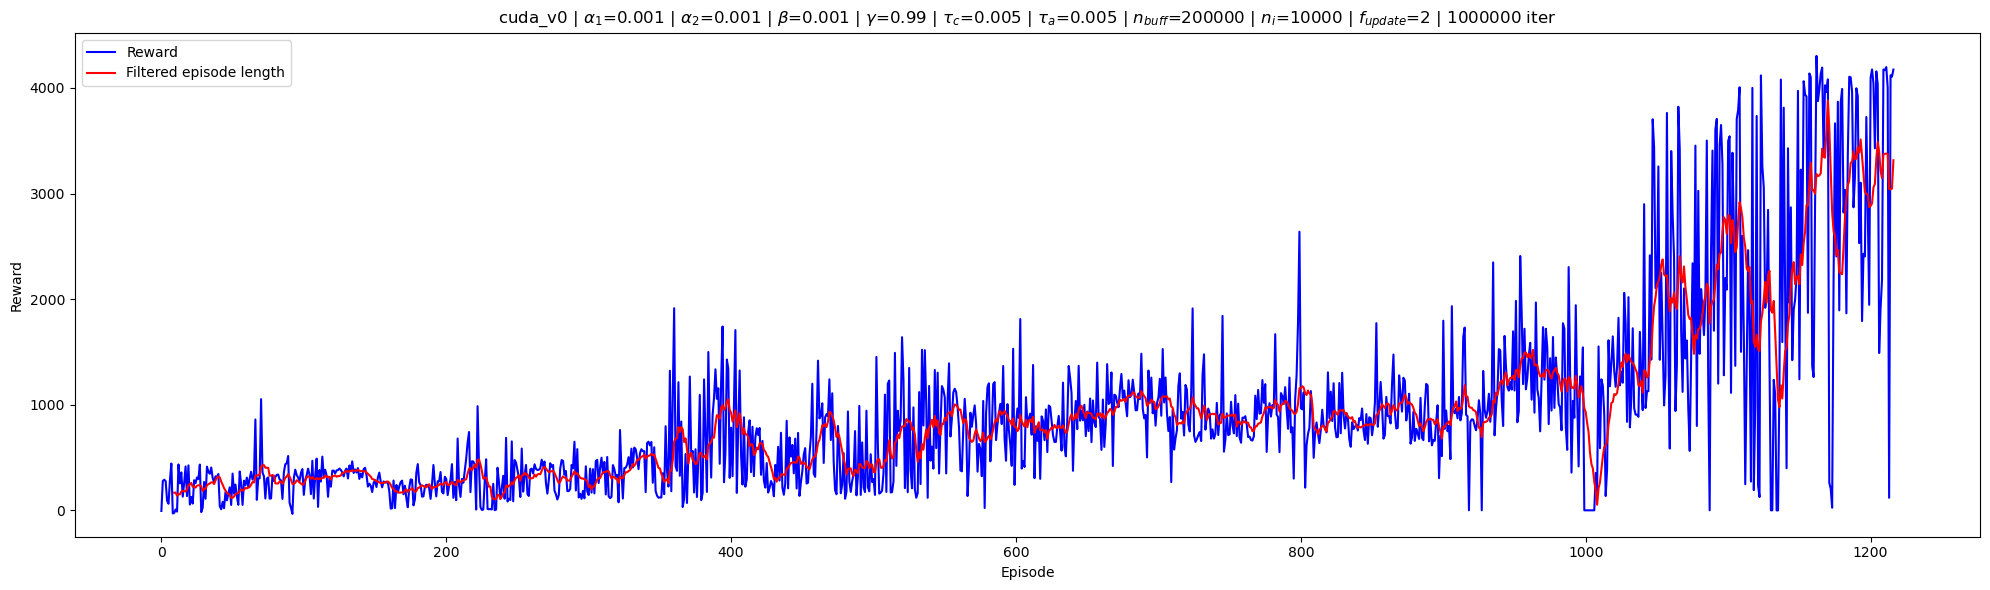

In [9]:
env = gym.make("Walker2d-v5",
               forward_reward_weight=1,     # weighting factor of the moving forward reward
               ctrl_cost_weight=1e-3,        # weighting factor of the large action penalty
               healthy_reward=1,
               terminate_when_unhealthy=True,
               healthy_z_range=(0.8,2),
               healthy_angle_range=(-1,1),
               reset_noise_scale=5e-3,       # scale of random pertubations in the initial state
               exclude_current_positions_from_observation=True
               )

for i in range(1):    
    seed = np.random.randint(1,100)
    TD3_experiment = TD3(model_name = MODEL_NAME, model_registry=model_registry, env=env,
                     alpha1=ALPHA1,alpha2=ALPHA2,beta=BETA,gamma=GAMMA,
                     tau_c=TAU_C,tau_a=TAU_A,sigma=SIGMA,clip=CLIP,
                     buffer_size=BUFFER_SIZE,buffer_init=BUFFER_INIT, batch_size=BATCH_SIZE, 
                     update_f=UPDATE_FREQ, update_step=UPDATE_STEP, iter=TRAIN_ITER,
                     seed=seed,
                     train_crit=TRAIN_CRIT,
                     result_folder=RESULT_FOLDER,
                     cuda_enabled=CUDA_ENABLED)                 
    TD3_experiment.train(early_stop=EARLY_STOP,verbose=True)